In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import librosa
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT / "src"))

Data_dir = Path(PROJECT_ROOT/"data"/"dev_data_fan")

wav_files = list(Data_dir.rglob("*.wav"))

def parse_filename(path):
    name = path.stem
    parts = name.split("_")

    return {
        "file": str(path),
        "filename": path.name,
        "section": parts[1],
        "domain": parts[2],
        "split": parts[3],
        "label": parts[4]
    }

records = [parse_filename(path) for path in wav_files]
df = pd.DataFrame(records)
df.head()

def extract_rms(y):
    return float(np.mean(librosa.feature.rms(y=y)))

def extract_zcr(y):
    return float(np.mean(librosa.feature.zero_crossing_rate(y)))

def extract_spectral_centroid(y,sr):
    return float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))

def extract_spectal_bandwidth(y,sr):
    return float(np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr)))

def extract_spectral_rolloff(y,sr):
    return float(np.mean(librosa.feature.spectral_rolloff(y=y,sr=sr)))

def extract_spectral_flatness(y):
    return float(np.mean(librosa.feature.spectral_flatness(y=y)))

def extract_features(path):
    y, sr = librosa.load(path, sr=None, mono=True)

    features = {
        "rms": extract_rms(y),
        "zcr": extract_zcr(y),
        "spectral_centroid": extract_spectral_centroid(y, sr),
        "spectral_bandwidth": extract_spectal_bandwidth(y, sr),
        "spectral_rolloff": extract_spectral_rolloff(y, sr),
        "spectral_flatness": extract_spectral_flatness(y)
    }

    return features

sample_path = df.iloc[0]["file"]

features = extract_features(sample_path)

features

{'rms': 0.014820185489952564,
 'zcr': 0.0970010483226837,
 'spectral_centroid': 1535.1450225046212,
 'spectral_bandwidth': 1715.5551267702538,
 'spectral_rolloff': 3346.845047923323,
 'spectral_flatness': 0.03605817258358002}

In [ ]:
from tqdm import tqdm
feature_records = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):
    features = extract_features(row["file"])

    feature_records.append({
        **row.to_dict(),
        **features
    })

feature_df = pd.DataFrame(feature_records)
feature_df.head()

Result_dir = Path(PROJECT_ROOT/"results")
Result_dir.mkdir(exist_ok=True)

feature_df.to_csv(
    Result_dir/ "acoustic_features.csv",
    index=False
)

100%|██████████| 4209/4209 [01:49<00:00, 38.58it/s]


In [45]:
Result_dir = Path(PROJECT_ROOT/"results")

feature_df = pd.read_csv(Result_dir/"acoustic_features.csv")

feature_df.groupby(["domain","label"])[
    [
        "rms",
        "zcr",
        "spectral_centroid",
        "spectral_bandwidth",
        "spectral_rolloff",
        "spectral_flatness"
    ]
].mean()

rms       zcr  spectral_centroid  spectral_bandwidth  \
domain label                                                                
source anomaly  0.016597  0.134617        1956.705642         1995.508177   
       normal   0.016643  0.138510        1986.100498         2002.493431   
target anomaly  0.016760  0.136419        1987.515422         2031.042942   
       normal   0.016622  0.137236        1967.979823         2000.159587   

                spectral_rolloff  spectral_flatness  
domain label                                         
source anomaly       4354.629093           0.073069  
       normal        4397.125009           0.078463  
target anomaly       4458.635849           0.076973  
       normal        4369.043673           0.079329

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

feature_columns = [
    "rms",
    "zcr",
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff",
    "spectral_flatness"
]

source_results = []

for feature in feature_columns:
    normal = feature_df[
        (feature_df["domain"] == "source") &
        (feature_df["label"] == "normal")
    ][feature].dropna()

    anomaly = feature_df[
        (feature_df["domain"] == "source") &
        (feature_df["label"] == "anomaly")
    ][feature].dropna()

    statistic, p_value = mannwhitneyu(
        normal,
        anomaly,
        alternative="two-sided"
    )

    source_results.append({
        "feature": feature,
        "p_value": p_value
    })

source_stats = pd.DataFrame(source_results)

reject, p_corrected, _, _ = multipletests(
    source_stats["p_value"],
    alpha=0.05,
    method="fdr_bh"
)
source_stats["p_value_corrected"] = p_corrected
source_stats["significant"] = reject
print(source_stats)

              feature   p_value  p_value_corrected  significant
0                 rms  0.008359           0.050152        False
1                 zcr  0.313217           0.378355        False
2   spectral_centroid  0.207606           0.378355        False
3  spectral_bandwidth  0.411789           0.411789        False
4    spectral_rolloff  0.315295           0.378355        False
5   spectral_flatness  0.212183           0.378355        False


In [18]:
target_results = []

for feature in feature_columns:
    normal = feature_df[
        (feature_df["domain"] == "target") &
        (feature_df["label"] == "normal")
    ][feature].dropna()

    anomaly = feature_df[
        (feature_df["domain"] == "target") &
        (feature_df["label"] == "anomaly")
    ][feature].dropna()

    statistic, p_value = mannwhitneyu(
        normal,
        anomaly,
        alternative="two-sided"
    )

    target_results.append({
        "feature": feature,
        "p_value": p_value
    })

target_stats = pd.DataFrame(target_results)

reject, p_corrected, _, _ = multipletests(
    target_stats["p_value"],
    alpha=0.05,
    method="fdr_bh"
)
target_stats["p_value_corrected"] = p_corrected
target_stats["significant"] = reject
print(target_stats)

              feature   p_value  p_value_corrected  significant
0                 rms  0.837215           0.964910        False
1                 zcr  0.964910           0.964910        False
2   spectral_centroid  0.567691           0.851536        False
3  spectral_bandwidth  0.128172           0.769035        False
4    spectral_rolloff  0.296653           0.851536        False
5   spectral_flatness  0.548495           0.851536        False


In [19]:
normal_results = []

for feature in feature_columns:
    source = feature_df[
        (feature_df["domain"] == "source") &
        (feature_df["label"] == "normal")
    ][feature].dropna()

    target = feature_df[
        (feature_df["domain"] == "target") &
        (feature_df["label"] == "normal")
    ][feature].dropna()

    statistic, p_value = mannwhitneyu(
        source,
        target,
        alternative="two-sided"
    )

    normal_results.append({
        "feature": feature,
        "p_value": p_value
    })

normal_stats = pd.DataFrame(normal_results)

reject, p_corrected, _, _ = multipletests(
    normal_stats["p_value"],
    alpha=0.05,
    method="fdr_bh"
)
normal_stats["p_value_corrected"] = p_corrected
normal_stats["significant"] = reject
print(normal_stats)

              feature       p_value  p_value_corrected  significant
0                 rms  2.483102e-11       1.489861e-10         True
1                 zcr  6.815952e-01       8.179143e-01        False
2   spectral_centroid  5.913787e-01       8.179143e-01        False
3  spectral_bandwidth  9.727403e-01       9.727403e-01        False
4    spectral_rolloff  6.785199e-01       8.179143e-01        False
5   spectral_flatness  1.477222e-01       4.431665e-01        False


In [46]:
source_stats = source_stats.copy()
target_stats = target_stats.copy()
normal_stats = normal_stats.copy()

source_stats["comparison"] = "source_normal_vs_anomaly"
target_stats["comparison"] = "target_normal_vs_anomaly"
normal_stats["comparison"] = "source_normal_vs_target_normal"

statistical_results = pd.concat(
[
    source_stats,
    target_stats,
    normal_stats
],
ignore_index=True)


cols = ["comparison"] + [col for col in statistical_results.columns
                         if col != "comparison"]

statistical_results = statistical_results[cols]

statistical_results.head()

Result_dir.mkdir(parents=True,exist_ok=True)

statistical_results.to_csv(
    Result_dir/"statistical_results.csv",
    index=False
)

print(f"Saved to: {Result_dir / 'statistical_results.csv'}")

Saved to: /Applications/FAU/Application/Akustische_industriellen_Kontexten/results/statistical_results.csv


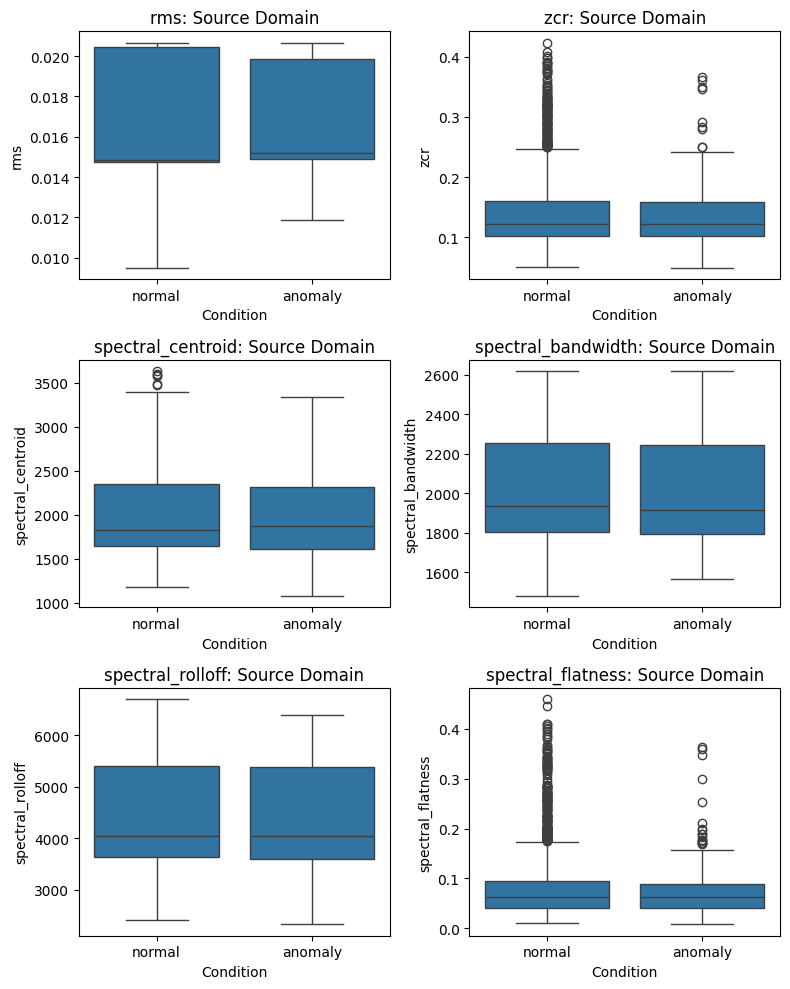

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(8,10))

for ax, feature in zip(axes.flat, feature_columns):

    sns.boxplot(
        data=feature_df[feature_df["domain"]=="source"],
        x="label",
        y=feature,
        ax=ax)

    ax.set_title(f"{feature}: Source Domain")
    ax.set_xlabel("Condition")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

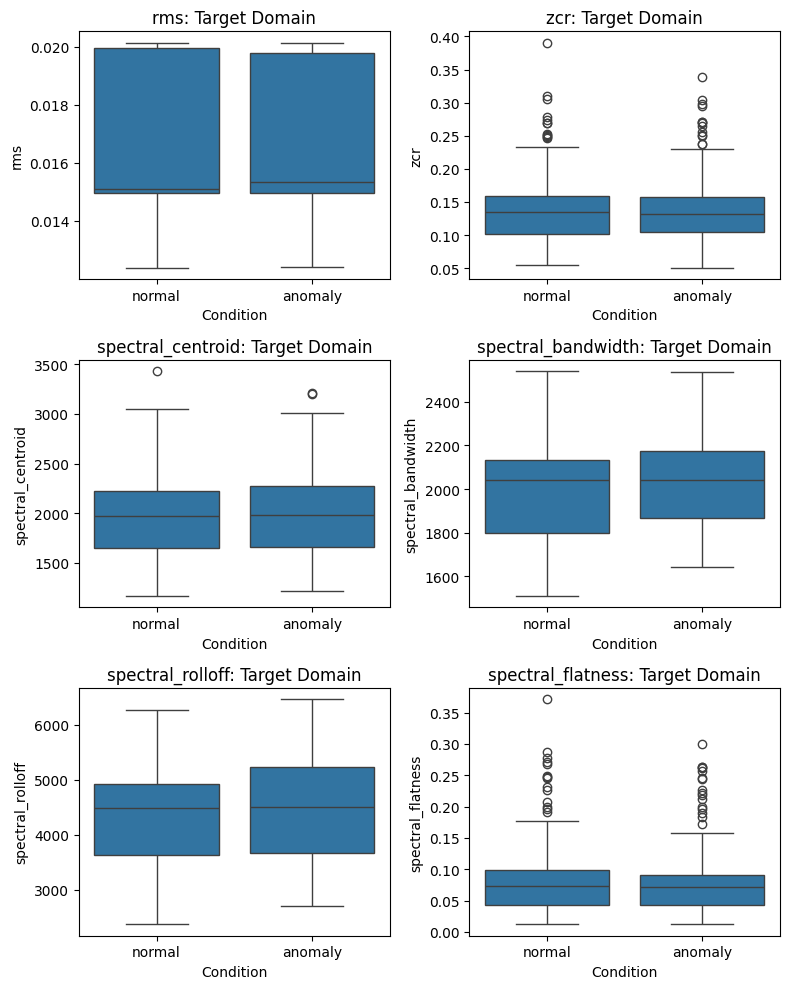

In [44]:
fig, axes = plt.subplots(3, 2, figsize=(8,10))

for ax, feature in zip(axes.flat, feature_columns):

    sns.boxplot(
        data=feature_df[feature_df["domain"]=="target"],
        x="label",
        y=feature,
        ax=ax)

    ax.set_title(f"{feature}: Target Domain")
    ax.set_xlabel("Condition")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

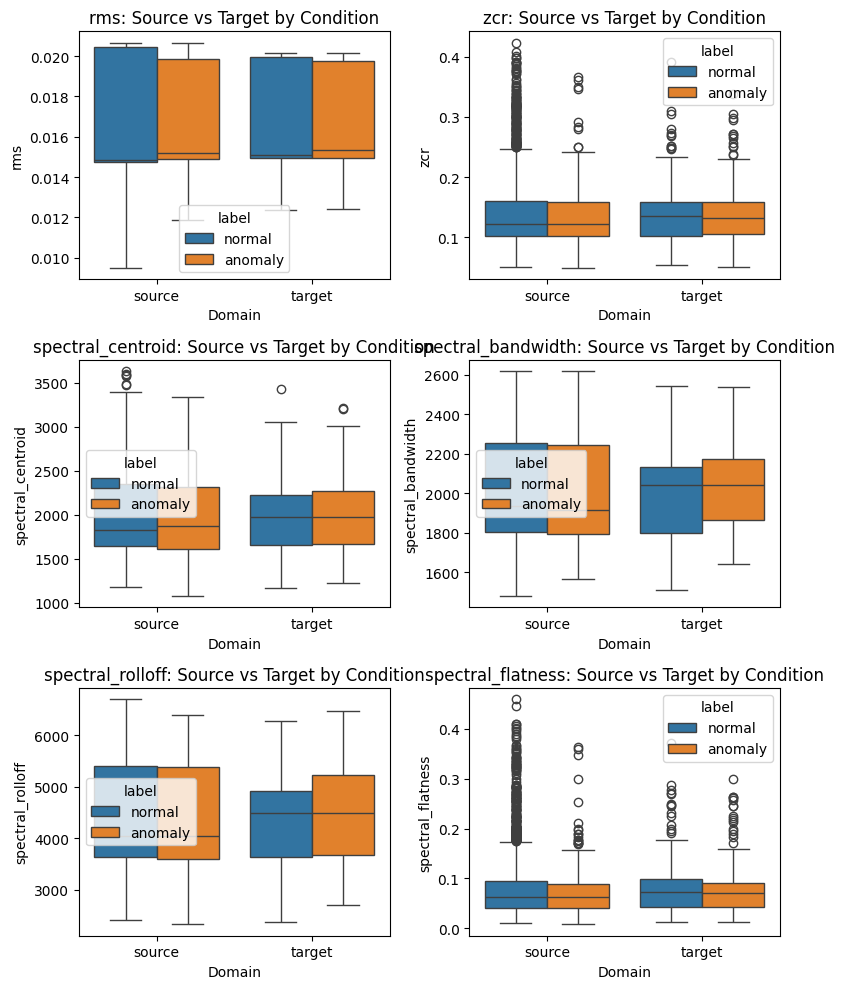

In [43]:
fig, axes = plt.subplots(3,2,figsize=(8,10))

for ax, feature in zip(axes.flat, feature_columns):

    sns.boxplot(
        data=feature_df,
        x="domain",
        y=feature,
        hue="label",
        ax=ax)

    ax.set_title(f"{feature}: Source vs Target by Condition")
    ax.set_xlabel("Domain")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()